# GNSS Log Analysis

**Device:** Xiaomi 2201116PI (Xiaomi 13) | Android 13 | GnssLogger v3.1.1.2  
**Chipset:** Qualcomm MPSS.HI.4.3.1  
**Log:** 2026-02-25 17:55 UTC | Bangalore, India (~13.067°N, 77.592°E, ~921 m)  

### Files analysed
| File | Format |
|------|---------|
| `gnss_log_2026_02_25_23_25_37.txt` | GnssLogger CSV (Raw + Fix + Status + IMU rows) |
| `gnss_log_2026_02_25_23_25_37.nmea` | NMEA 0183 sentences |
| `gnss_log_2026_02_25_23_25_37.26o` | RINEX 4.01 observation file |

### Sections
1. Setup & imports
2. Raw GNSS measurements — CN0, pseudorange, Doppler
3. Fix measurements — provider comparison & accuracy
4. Status rows — sky plot, CN0 box plot, tracked vs used
5. NMEA — GGA position & altitude
6. RINEX 4.01 — epoch & system summary
7. Summary dashboard

---
## 1  Setup & Imports

In [1]:
# Install dependencies if running in Colab
# !pip install gnss-lib-py pynmea2 georinex -q

import os, warnings
warnings.filterwarnings('ignore')

import gnss_lib_py as glp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import pynmea2

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

print(f'gnss-lib-py  : {glp.__version__}')
print(f'numpy        : {np.__version__}')
print(f'pandas       : {pd.__version__}')

gnss-lib-py  : 1.0.4
numpy        : 2.4.0
pandas       : 2.3.1


In [2]:
# ── File paths ─────────────────────────────────────────────────────────────
LOG_DIR    = os.getcwd()   # notebook lives next to the log files
TXT_FILE   = os.path.join(LOG_DIR, 'gnss_log_2026_02_25_23_25_37.txt')
NMEA_FILE  = os.path.join(LOG_DIR, 'gnss_log_2026_02_25_23_25_37.nmea')
RINEX_FILE = os.path.join(LOG_DIR, 'gnss_log_2026_02_25_23_25_37.26o')

for f in [TXT_FILE, NMEA_FILE, RINEX_FILE]:
    size = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):45s}  {size:7.1f} KB')

# ── Shared colour map ──────────────────────────────────────────────────────
CONST_COLOUR = {
    'gps':     '#1f77b4',
    'glonass': '#ff7f0e',
    'galileo': '#2ca02c',
    'beidou':  '#d62728',
    'qzss':    '#9467bd',
    'sbas':    '#8c564b',
    'navic':   '#e377c2',
    'GPS':     '#1f77b4',
    'GLONASS': '#ff7f0e',
    'Galileo': '#2ca02c',
    'BeiDou':  '#d62728',
    'QZSS':    '#9467bd',
}
CONST_NAMES_INT = {1:'GPS', 2:'SBAS', 3:'GLONASS', 4:'QZSS',
                   5:'BeiDou', 6:'Galileo', 7:'NavIC'}
RINEX_SYS = {'G':'GPS','R':'GLONASS','E':'Galileo',
              'C':'BeiDou','J':'QZSS','S':'SBAS','I':'NavIC'}

  gnss_log_2026_02_25_23_25_37.txt                2503.3 KB
  gnss_log_2026_02_25_23_25_37.nmea                 80.1 KB
  gnss_log_2026_02_25_23_25_37.26o                  19.6 KB


---
## 2  Raw GNSS Measurements

Parsed from `Raw` rows in the `.txt` file via `gnss_lib_py.AndroidRawGnss`.

> **Filter note:** The default `BiasUncertaintyNanos` threshold of 40 ns rejects **all** measurements
> from this Xiaomi device (chipset reports 75–129 ns). The filter is relaxed to 200 ns, which is
> appropriate for mid-range Qualcomm chipsets.

In [3]:
relaxed_filters = {
    'bias_valid':             True,
    'bias_uncertainty':       200.0,   # relaxed: chipset reports 75-129 ns
    'arrival_time':           True,
    'unknown_constellations': True,
    'time_valid':             True,
    'state_decoded':          True,
    'sv_time_uncertainty':    500.0,
}

raw = glp.AndroidRawGnss(TXT_FILE, measurement_filters=relaxed_filters, verbose=False)
t_ms  = raw['gps_millis']
t_sec = (t_ms - t_ms[0]) / 1000.0

print(f'Measurements after filtering : {raw.shape[1]}')
print(f'Constellations               : {np.unique(raw["gnss_id"]).tolist()}')
print()

# Constellation count table
consts, counts = np.unique(raw['gnss_id'], return_counts=True)
df_count = pd.DataFrame({'Constellation': consts, 'Measurements': counts})
display(df_count.set_index('Constellation'))

Measurements after filtering : 311
Constellations               : [np.str_('beidou'), np.str_('galileo'), np.str_('glonass'), np.str_('gps'), np.str_('qzss')]



,Measurements
Constellation,
beidou,71
galileo,31
glonass,83
gps,95
qzss,31


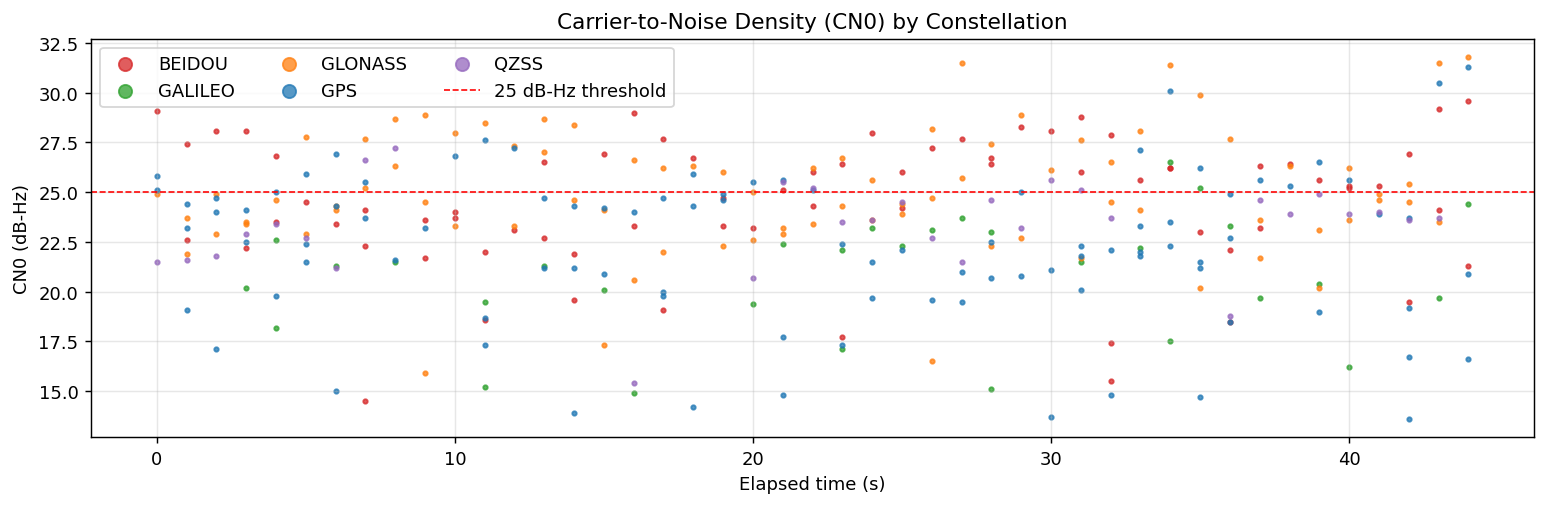

In [4]:
# ── CN0 over time ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
for c in np.unique(raw['gnss_id']):
    mask = raw['gnss_id'] == c
    ax.scatter(t_sec[mask], raw['cn0_dbhz'][mask],
               s=6, alpha=0.75, color=CONST_COLOUR.get(c, '#555'),
               label=c.upper())
ax.axhline(25, color='red', linewidth=0.9, linestyle='--', label='25 dB-Hz threshold')
ax.set_xlabel('Elapsed time (s)')
ax.set_ylabel('CN0 (dB-Hz)')
ax.set_title('Carrier-to-Noise Density (CN0) by Constellation')
ax.legend(markerscale=3, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# ── CN0 statistics ─────────────────────────────────────────────────────────
cn0 = raw['cn0_dbhz']
stats = pd.DataFrame({
    'Mean':   [round(float(np.mean(cn0)), 1)],
    'Median': [round(float(np.median(cn0)), 1)],
    'Min':    [round(float(np.min(cn0)), 1)],
    'Max':    [round(float(np.max(cn0)), 1)],
    'Std':    [round(float(np.std(cn0)), 1)],
}, index=['CN0 (dB-Hz)'])
display(stats)

,Mean,Median,Min,Max,Std
CN0 (dB-Hz),23.4,23.7,13.6,31.8,3.6


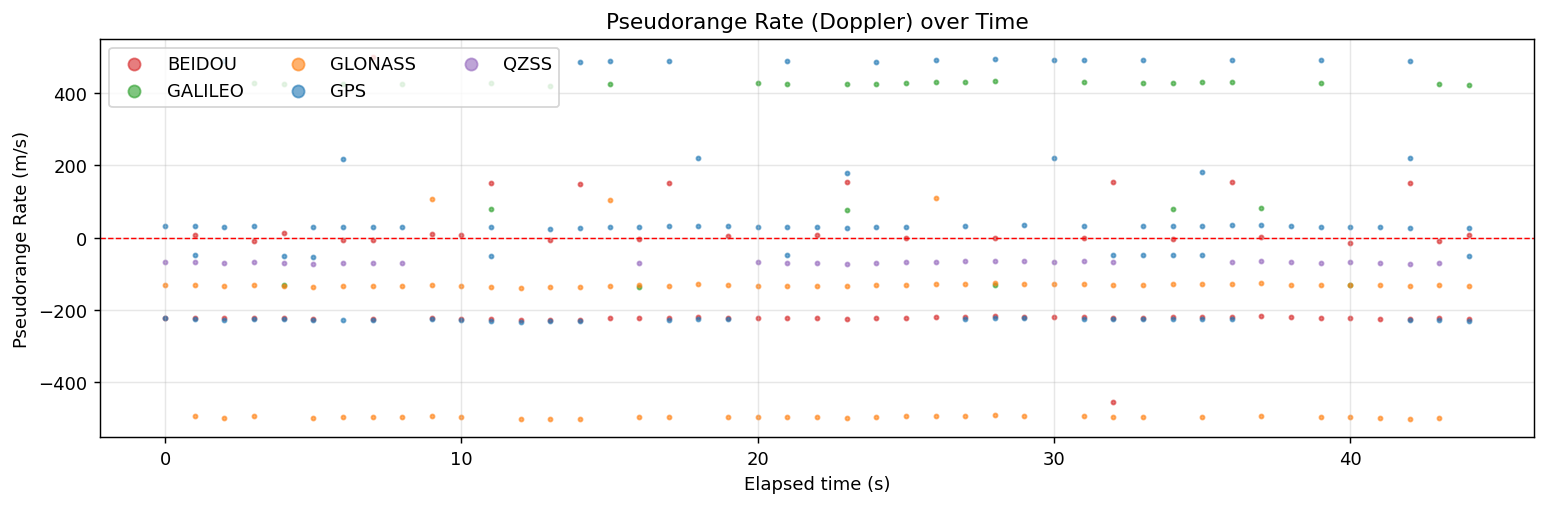

In [6]:
# ── Pseudorange Rate (Doppler) ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
prr = raw['PseudorangeRateMetersPerSecond']
for c in np.unique(raw['gnss_id']):
    mask = raw['gnss_id'] == c
    ax.scatter(t_sec[mask], prr[mask],
               s=5, alpha=0.6, color=CONST_COLOUR.get(c, '#555'),
               label=c.upper())
ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax.set_xlabel('Elapsed time (s)')
ax.set_ylabel('Pseudorange Rate (m/s)')
ax.set_title('Pseudorange Rate (Doppler) over Time')
ax.legend(markerscale=3, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

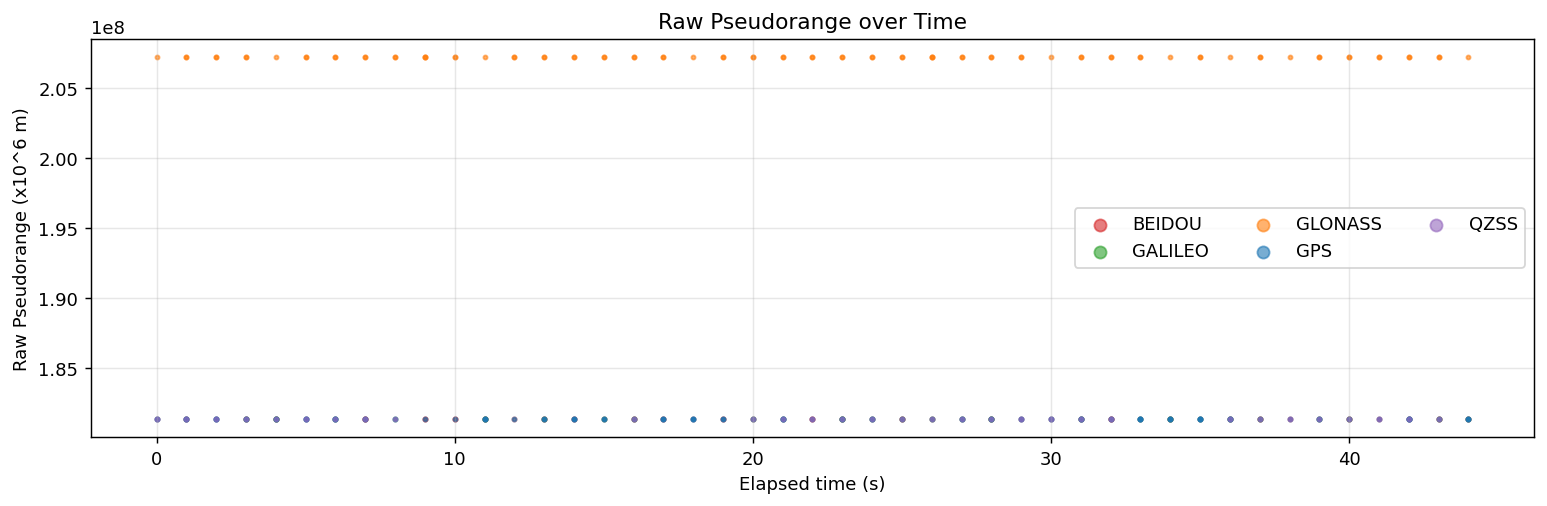

In [7]:
# ── Raw Pseudorange ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
pr = raw['raw_pr_m']
for c in np.unique(raw['gnss_id']):
    mask = raw['gnss_id'] == c
    ax.scatter(t_sec[mask], pr[mask] / 1e6,
               s=5, alpha=0.6, color=CONST_COLOUR.get(c, '#555'),
               label=c.upper())
ax.set_xlabel('Elapsed time (s)')
ax.set_ylabel('Raw Pseudorange (x10^6 m)')
ax.set_title('Raw Pseudorange over Time')
ax.legend(markerscale=3, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3  Fix Measurements

Parsed from `Fix` rows via `gnss_lib_py.AndroidRawFixes`.  
Providers reported: **GNSS** (raw chipset), **Fused** (sensor fusion), **Network** (cell/Wi-Fi).

In [8]:
fixes = glp.AndroidRawFixes(TXT_FILE)

prov_key = 'fix_provider' if 'fix_provider' in fixes.rows else 'provider'
lat_key  = 'lat_rx_deg'   if 'lat_rx_deg'   in fixes.rows else 'lat_deg'
lon_key  = 'lon_rx_deg'   if 'lon_rx_deg'   in fixes.rows else 'lng_deg'
acc_key  = 'AccuracyMeters' if 'AccuracyMeters' in fixes.rows else 'accuracy_m'

providers = np.unique(fixes[prov_key]) if prov_key in fixes.rows else []
print(f'Providers : {list(providers)}')
print(f'Total fix rows : {fixes.shape[1]}')

Providers : [np.str_('fused'), np.str_('gnss'), np.str_('network')]
Total fix rows : 95


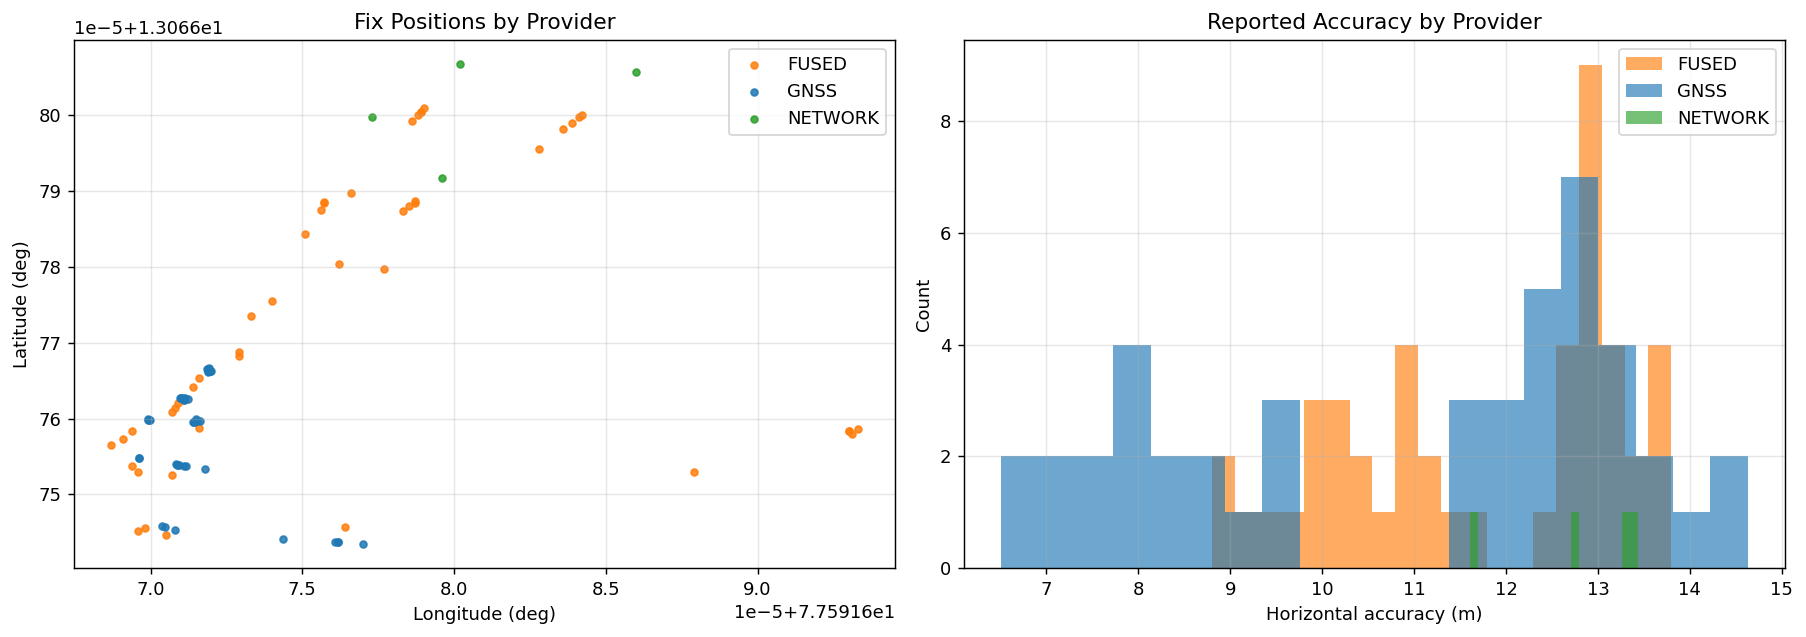

In [9]:
# ── Fix positions by provider ──────────────────────────────────────────────
prov_col = {'gps':'#1f77b4','fused':'#ff7f0e','network':'#2ca02c','gnss':'#1f77b4'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter map
ax = axes[0]
for p in providers:
    mask = fixes[prov_key] == p
    ax.scatter(fixes[lon_key][mask], fixes[lat_key][mask],
               s=14, alpha=0.85, label=p.upper(),
               color=prov_col.get(p.lower(), '#555'))
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
ax.set_title('Fix Positions by Provider')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy histogram
ax = axes[1]
if acc_key in fixes.rows:
    for p in providers:
        mask = fixes[prov_key] == p
        ax.hist(fixes[acc_key][mask], bins=20, alpha=0.65,
                label=p.upper(), color=prov_col.get(p.lower(), '#555'))
    ax.set_xlabel('Horizontal accuracy (m)')
    ax.set_ylabel('Count')
    ax.set_title('Reported Accuracy by Provider')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ── Accuracy statistics per provider ──────────────────────────────────────
if acc_key in fixes.rows:
    rows = []
    for p in providers:
        mask = fixes[prov_key] == p
        vals = fixes[acc_key][mask]
        rows.append({'Provider': p.upper(),
                     'Count':  int(np.sum(mask)),
                     'Mean (m)':   round(float(np.mean(vals)), 2),
                     'Median (m)': round(float(np.median(vals)), 2),
                     'Min (m)':    round(float(np.min(vals)), 2),
                     'Max (m)':    round(float(np.max(vals)), 2)})
    display(pd.DataFrame(rows).set_index('Provider'))

,Count,Mean (m),Median (m),Min (m),Max (m)
Provider,,,,,
FUSED,46,11.76,12.51,8.80,13.79
GNSS,45,10.91,11.84,6.51,14.63
NETWORK,4,12.79,13.06,11.61,13.44


---
## 4  Status Rows — Sky Plot, CN0, Tracked vs Used

Parsed directly from `Status` rows in the `.txt` file.  
Each row contains: constellation, SVID, CN0, azimuth, elevation, and whether the SV was used in fix.

In [11]:
status_rows = []
with open(TXT_FILE) as f:
    for line in f:
        if not line.startswith('Status,'):
            continue
        p = line.strip().split(',')
        try:
            status_rows.append({
                't_ms':  float(p[1]),
                'const': int(p[4]),
                'svid':  int(p[5]),
                'cn0':   float(p[7]),
                'az':    float(p[8]),
                'el':    float(p[9]),
                'used':  p[10].strip() == '1',
            })
        except (ValueError, IndexError):
            pass

df = pd.DataFrame(status_rows)
df['const_name'] = df['const'].map(CONST_NAMES_INT).fillna('Unknown')
df['t_sec'] = (df['t_ms'] - df['t_ms'].iloc[0]) / 1000.0

print(f'Status rows     : {len(df)}')
print(f'Constellations  : {sorted(df["const_name"].unique())}')
print(f'Time span       : {df["t_sec"].max():.1f} s')

Status rows     : 2156
Constellations  : ['BeiDou', 'GLONASS', 'GPS', 'Galileo', 'QZSS']
Time span       : 43.0 s


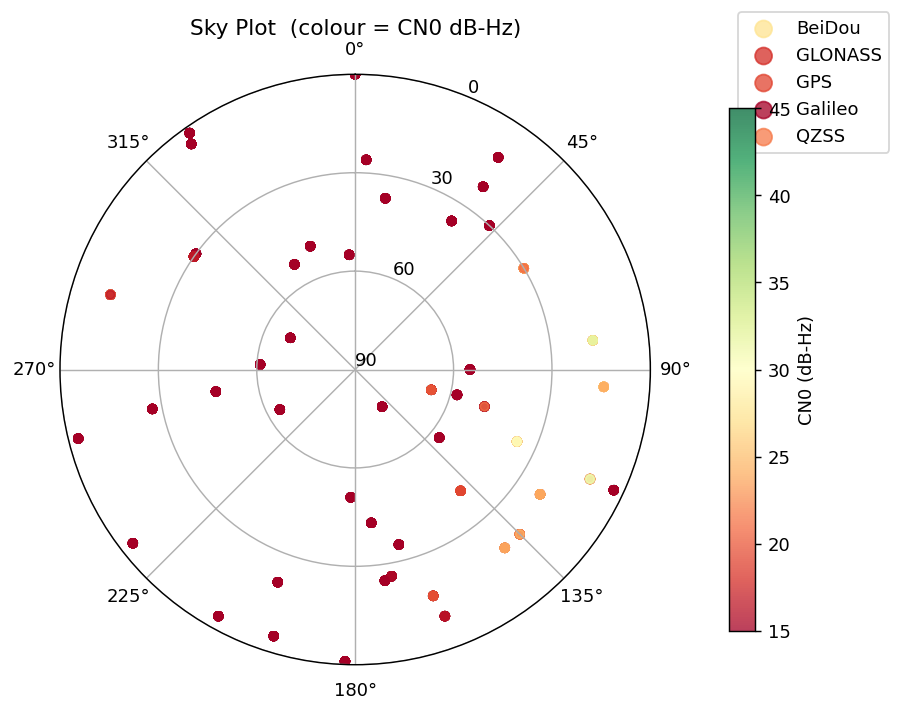

In [12]:
# ── Sky plot ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, projection='polar')

for c, grp in df.groupby('const_name'):
    sc = ax.scatter(
        np.deg2rad(grp['az']), 90 - grp['el'],
        c=grp['cn0'], cmap='RdYlGn', vmin=15, vmax=45,
        s=22, alpha=0.75, label=c
    )

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_ylim(0, 90)
ax.set_yticks([0, 30, 60, 90])
ax.set_yticklabels(['90', '60', '30', '0'])
ax.set_title('Sky Plot  (colour = CN0 dB-Hz)', va='bottom', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.42, 1.12), markerscale=2)
fig.colorbar(sc, ax=ax, label='CN0 (dB-Hz)', shrink=0.6, pad=0.1)
plt.tight_layout()
plt.show()

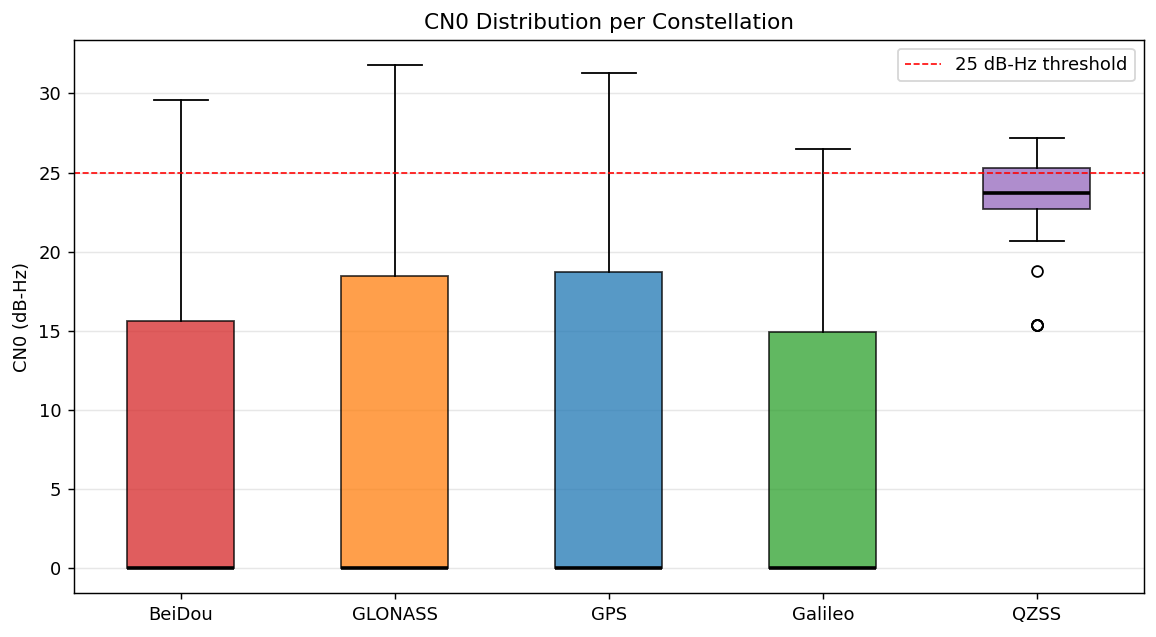

In [13]:
# ── CN0 box plot per constellation ─────────────────────────────────────────
const_list = sorted(df['const_name'].unique())
data_list  = [df[df['const_name'] == c]['cn0'].values for c in const_list]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data_list, labels=const_list, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], const_list):
    patch.set_facecolor(CONST_COLOUR.get(c, '#aaa'))
    patch.set_alpha(0.75)
ax.axhline(25, color='red', linewidth=0.9, linestyle='--', label='25 dB-Hz threshold')
ax.set_ylabel('CN0 (dB-Hz)')
ax.set_title('CN0 Distribution per Constellation')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

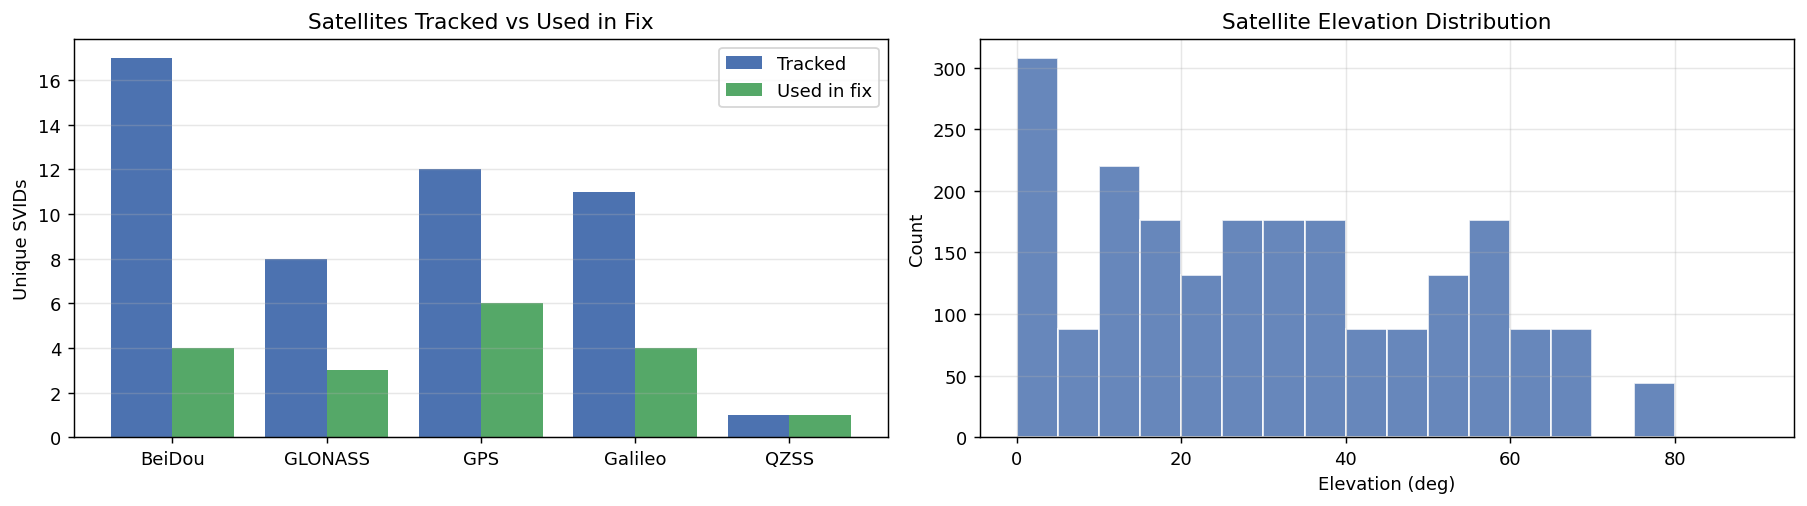

In [14]:
# ── Satellites tracked vs used ─────────────────────────────────────────────
tracked = df.groupby('const_name')['svid'].nunique()
used    = df[df['used']].groupby('const_name')['svid'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
ax = axes[0]
x = np.arange(len(tracked))
ax.bar(x - 0.2, tracked.values, 0.4, label='Tracked', color='#4c72b0')
ax.bar(x + 0.2, used.reindex(tracked.index, fill_value=0).values,
       0.4, label='Used in fix', color='#55a868')
ax.set_xticks(x)
ax.set_xticklabels(tracked.index)
ax.set_ylabel('Unique SVIDs')
ax.set_title('Satellites Tracked vs Used in Fix')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Elevation histogram
ax = axes[1]
ax.hist(df['el'], bins=18, range=(0, 90),
        color='#4c72b0', edgecolor='white', alpha=0.85)
ax.set_xlabel('Elevation (deg)')
ax.set_ylabel('Count')
ax.set_title('Satellite Elevation Distribution')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

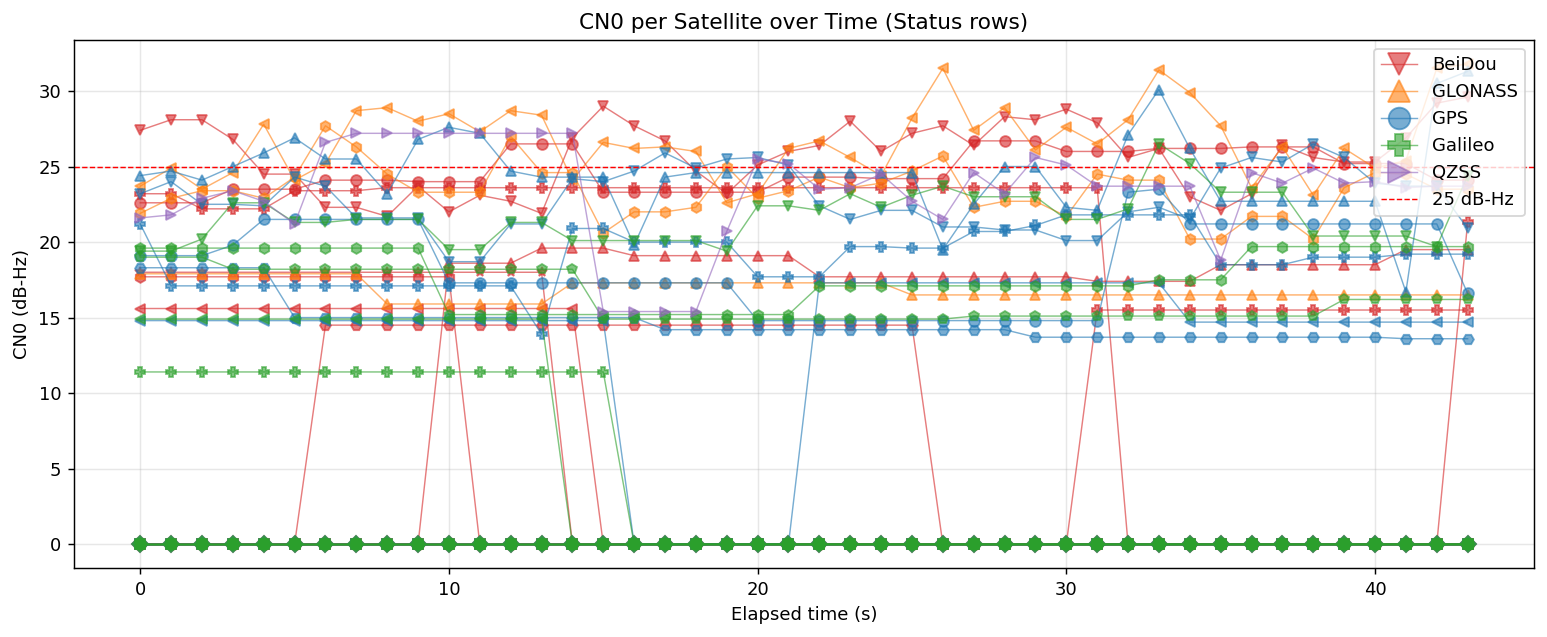

In [15]:
# ── CN0 per SV over time ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for c, grp in df.groupby('const_name'):
    for svid, sv_grp in grp.groupby('svid'):
        ax.plot(sv_grp['t_sec'], sv_grp['cn0'],
                linewidth=0.8, alpha=0.6,
                color=CONST_COLOUR.get(c, '#555'),
                label=f'{c}' if svid == grp['svid'].iloc[0] else '_')
ax.axhline(25, color='red', linewidth=0.8, linestyle='--', label='25 dB-Hz')
ax.set_xlabel('Elapsed time (s)')
ax.set_ylabel('CN0 (dB-Hz)')
ax.set_title('CN0 per Satellite over Time (Status rows)')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5  NMEA — GGA Position & Altitude

Parses `$GNGGA` / `$GPGGA` sentences from the `.nmea` file.  
GGA provides: latitude, longitude, altitude, HDOP, and number of satellites.

In [16]:
gga_rows = []
with open(NMEA_FILE) as f:
    for line in f:
        if not line.startswith('NMEA,'):
            continue
        parts = line.strip().split(',')
        if 'GGA' not in parts[1]:
            continue
        try:
            msg = pynmea2.parse(','.join(parts[1:-1]))
            if msg.latitude and msg.longitude:
                gga_rows.append({
                    'lat':         msg.latitude,
                    'lon':         msg.longitude,
                    'alt':         float(msg.altitude),
                    'hdop':        float(msg.horizontal_dil),
                    'fix_quality': int(msg.gps_qual),
                    'num_sats':    int(msg.num_sats),
                    'ts_ms':       float(parts[-1]),
                })
        except Exception:
            pass

gdf = pd.DataFrame(gga_rows)
gdf['t_sec'] = (gdf['ts_ms'] - gdf['ts_ms'].iloc[0]) / 1000.0

print(f'GGA fixes parsed : {len(gdf)}')
summary = pd.DataFrame({
    'Latitude (deg)':  [f"{gdf['lat'].min():.6f}  to  {gdf['lat'].max():.6f}"],
    'Longitude (deg)': [f"{gdf['lon'].min():.6f}  to  {gdf['lon'].max():.6f}"],
    'Altitude (m)':    [f"{gdf['alt'].min():.1f}  to  {gdf['alt'].max():.1f}"],
    'HDOP mean':       [round(gdf['hdop'].mean(), 2)],
    'Sats mean':       [round(gdf['num_sats'].mean(), 1)],
}, index=['Value'])
display(summary.T)

GGA fixes parsed : 45


,Value
Latitude (deg),13.066743 to 13.066767
Longitude (deg),77.591670 to 77.591677
Altitude (m),920.3 to 921.7
HDOP mean,1.02
Sats mean,10.1


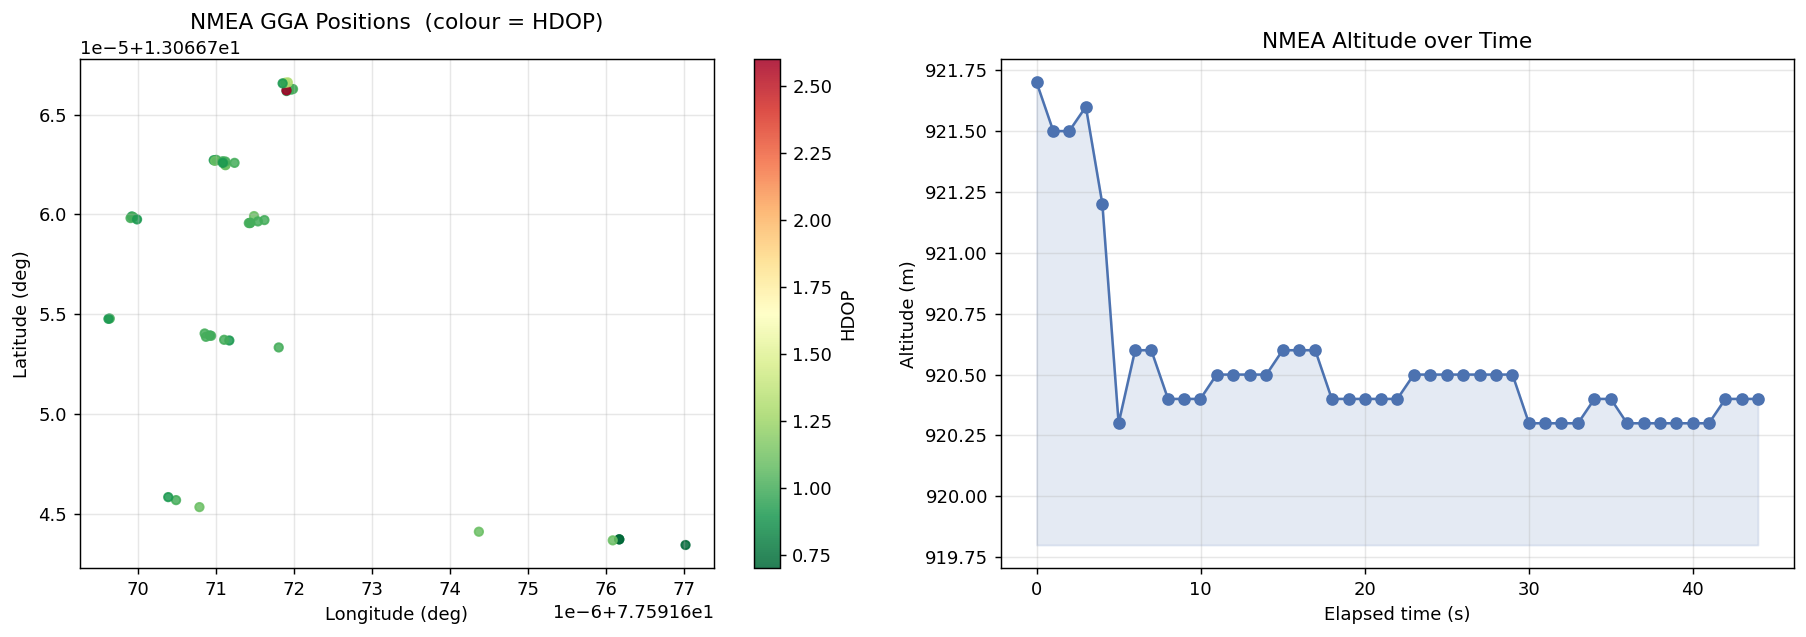

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Position scatter coloured by HDOP
ax = axes[0]
sc = ax.scatter(gdf['lon'], gdf['lat'], c=gdf['hdop'],
                cmap='RdYlGn_r', s=22, alpha=0.85)
fig.colorbar(sc, ax=ax, label='HDOP')
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
ax.set_title('NMEA GGA Positions  (colour = HDOP)')
ax.grid(True, alpha=0.3)

# Altitude over time
ax = axes[1]
ax.plot(gdf['t_sec'], gdf['alt'], color='#4c72b0', linewidth=1.4)
ax.fill_between(gdf['t_sec'], gdf['alt'],
                gdf['alt'].min() - 0.5, alpha=0.15, color='#4c72b0')
ax.set_xlabel('Elapsed time (s)')
ax.set_ylabel('Altitude (m)')
ax.set_title('NMEA Altitude over Time')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

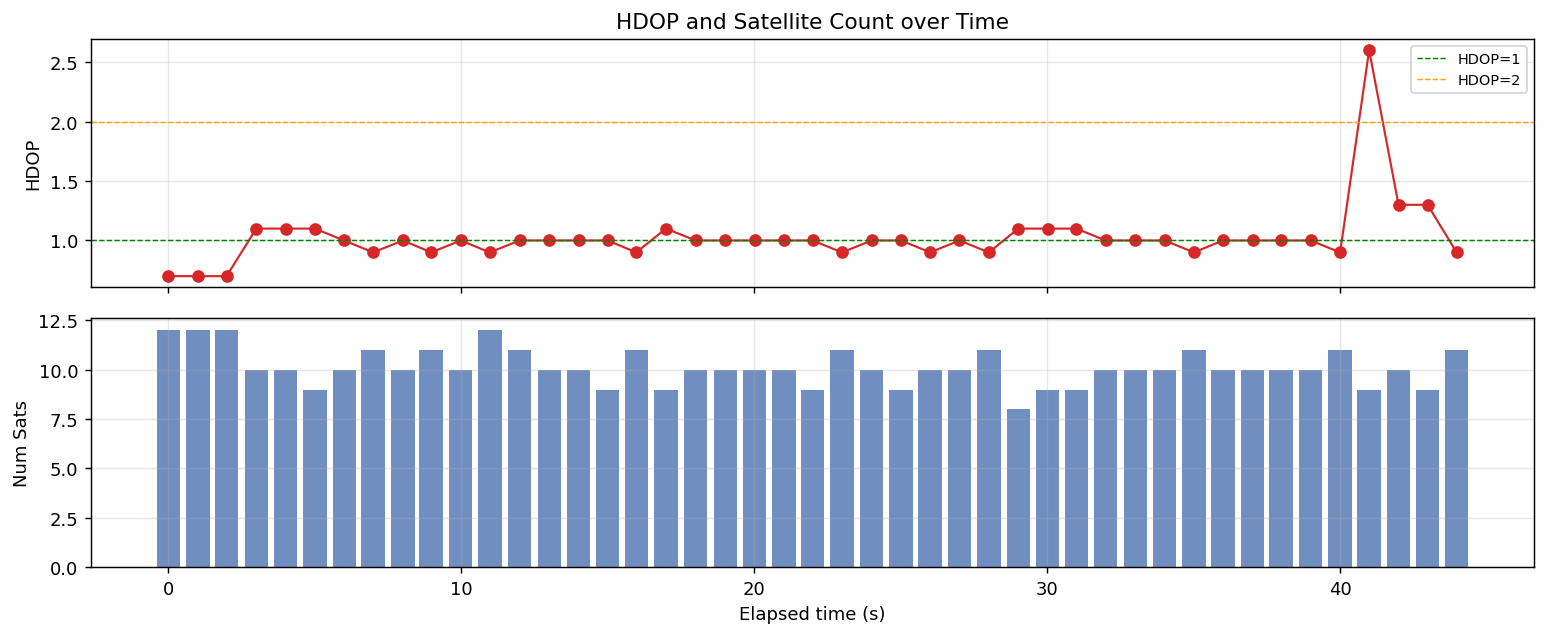

In [18]:
# ── HDOP and satellite count over time ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

ax1.plot(gdf['t_sec'], gdf['hdop'], color='#d62728', linewidth=1.2)
ax1.axhline(1.0, color='green', linewidth=0.8, linestyle='--', label='HDOP=1')
ax1.axhline(2.0, color='orange', linewidth=0.8, linestyle='--', label='HDOP=2')
ax1.set_ylabel('HDOP')
ax1.set_title('HDOP and Satellite Count over Time')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.bar(gdf['t_sec'], gdf['num_sats'], width=0.8, color='#4c72b0', alpha=0.8)
ax2.set_ylabel('Num Sats')
ax2.set_xlabel('Elapsed time (s)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6  RINEX 4.01 Observation Summary

Parses the `.26o` RINEX 4.01 observation file directly to count epochs and systems.

In [19]:
epochs, systems, obs_per_epoch = 0, set(), []
current_count = 0

with open(RINEX_FILE) as f:
    in_header = True
    for line in f:
        if 'END OF HEADER' in line:
            in_header = False
            continue
        if not in_header:
            if line.startswith('>'):
                if epochs > 0:
                    obs_per_epoch.append(current_count)
                epochs += 1
                current_count = 0
            elif line.strip() and not line.startswith('>'):
                systems.add(line[0])
                current_count += 1
if current_count:
    obs_per_epoch.append(current_count)

print(f'Epochs  : {epochs}')
print(f'Systems : {[RINEX_SYS.get(s, s) for s in sorted(systems)]}')
print(f'Avg SVs/epoch : {np.mean(obs_per_epoch):.1f}')
print(f'Max SVs/epoch : {max(obs_per_epoch)}')

rinex_summary = pd.DataFrame({
    'Metric': ['Epochs', 'Systems', 'Avg SVs/epoch', 'Max SVs/epoch'],
    'Value':  [epochs,
               ', '.join(RINEX_SYS.get(s, s) for s in sorted(systems)),
               round(np.mean(obs_per_epoch), 1),
               max(obs_per_epoch)]
})
display(rinex_summary.set_index('Metric'))

Epochs  : 45
Systems : ['BeiDou', 'Galileo', 'GPS', 'QZSS', 'GLONASS']
Avg SVs/epoch : 6.9
Max SVs/epoch : 9


,Value
Metric,
Epochs,45
Systems,"BeiDou, Galileo, GPS, QZSS, GLONASS"
Avg SVs/epoch,6.9
Max SVs/epoch,9


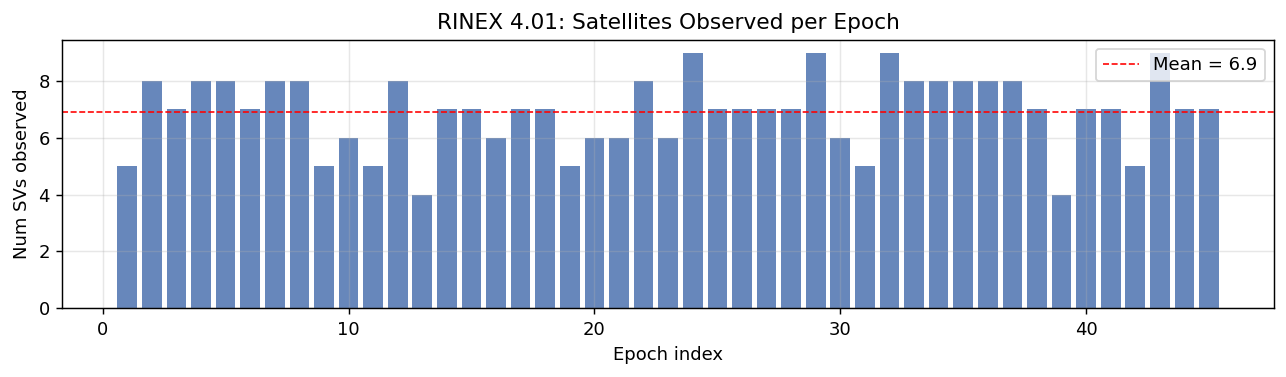

In [20]:
# ── SVs per epoch ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(1, len(obs_per_epoch) + 1), obs_per_epoch,
       color='#4c72b0', alpha=0.85)
ax.axhline(np.mean(obs_per_epoch), color='red', linewidth=0.9,
           linestyle='--', label=f'Mean = {np.mean(obs_per_epoch):.1f}')
ax.set_xlabel('Epoch index')
ax.set_ylabel('Num SVs observed')
ax.set_title('RINEX 4.01: Satellites Observed per Epoch')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7  Summary Dashboard

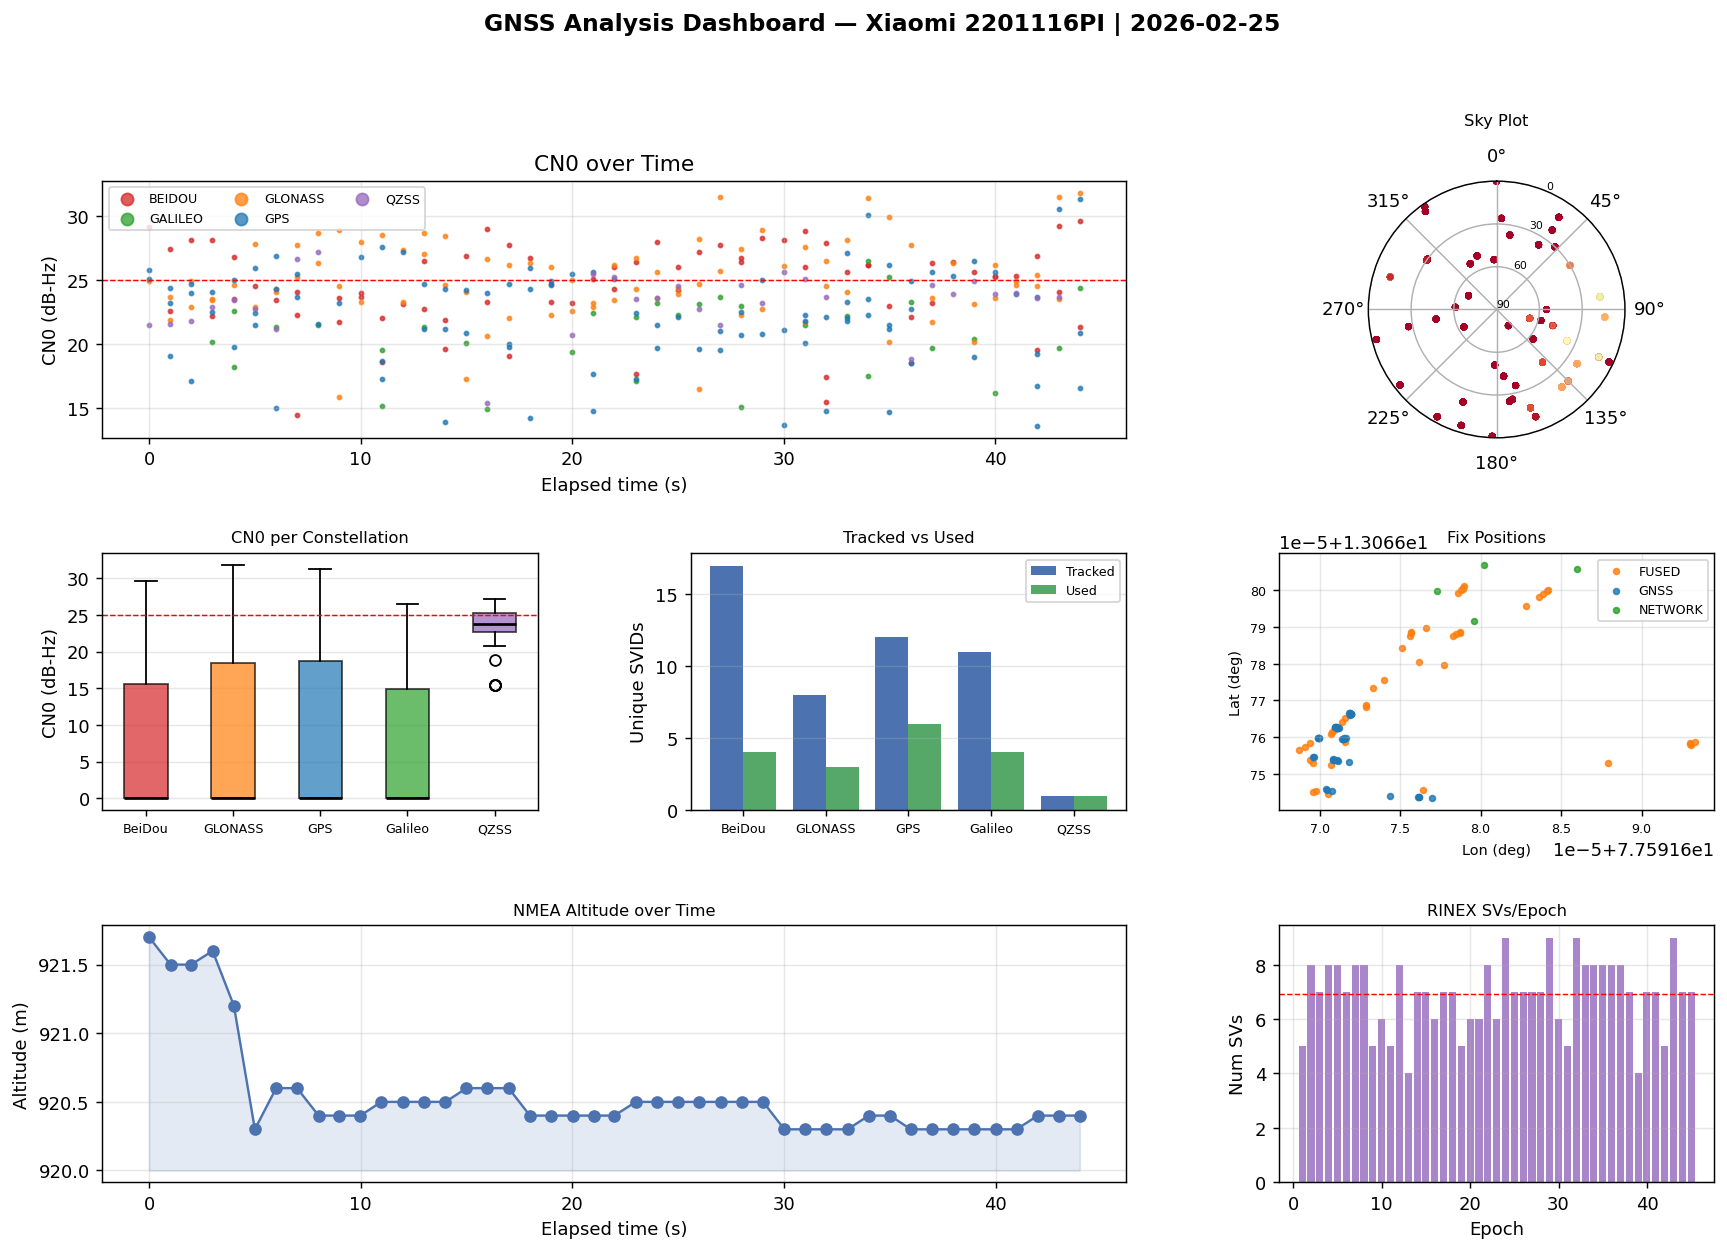

In [21]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. CN0 by constellation (top-left, wide)
ax1 = fig.add_subplot(gs[0, :2])
for c in np.unique(raw['gnss_id']):
    mask = raw['gnss_id'] == c
    ax1.scatter(t_sec[mask], raw['cn0_dbhz'][mask],
                s=5, alpha=0.75, color=CONST_COLOUR.get(c, '#555'), label=c.upper())
ax1.axhline(25, color='red', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Elapsed time (s)'); ax1.set_ylabel('CN0 (dB-Hz)')
ax1.set_title('CN0 over Time'); ax1.legend(markerscale=3, ncol=3, fontsize=7)
ax1.grid(True, alpha=0.3)

# 2. Sky plot (top-right)
ax2 = fig.add_subplot(gs[0, 2], projection='polar')
for c, grp in df.groupby('const_name'):
    ax2.scatter(np.deg2rad(grp['az']), 90 - grp['el'],
                c=grp['cn0'], cmap='RdYlGn', vmin=15, vmax=45,
                s=8, alpha=0.7)
ax2.set_theta_zero_location('N'); ax2.set_theta_direction(-1)
ax2.set_ylim(0, 90); ax2.set_yticks([0, 30, 60, 90])
ax2.set_yticklabels(['90', '60', '30', '0'], fontsize=6)
ax2.set_title('Sky Plot', fontsize=9, pad=12)

# 3. CN0 boxplot (mid-left)
ax3 = fig.add_subplot(gs[1, 0])
bp  = ax3.boxplot([df[df['const_name'] == c]['cn0'].values for c in const_list],
                  labels=const_list, patch_artist=True,
                  medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], const_list):
    patch.set_facecolor(CONST_COLOUR.get(c, '#aaa')); patch.set_alpha(0.7)
ax3.axhline(25, color='red', linewidth=0.8, linestyle='--')
ax3.set_title('CN0 per Constellation', fontsize=9)
ax3.set_ylabel('CN0 (dB-Hz)'); ax3.grid(True, axis='y', alpha=0.3)
ax3.tick_params(axis='x', labelsize=7)

# 4. Tracked vs used (mid-centre)
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(tracked))
ax4.bar(x - 0.2, tracked.values, 0.4, label='Tracked', color='#4c72b0')
ax4.bar(x + 0.2, used.reindex(tracked.index, fill_value=0).values,
        0.4, label='Used', color='#55a868')
ax4.set_xticks(x); ax4.set_xticklabels(tracked.index, fontsize=7)
ax4.set_ylabel('Unique SVIDs'); ax4.set_title('Tracked vs Used', fontsize=9)
ax4.legend(fontsize=7); ax4.grid(True, axis='y', alpha=0.3)

# 5. Fix positions (mid-right)
ax5 = fig.add_subplot(gs[1, 2])
for p in providers:
    mask = fixes[prov_key] == p
    ax5.scatter(fixes[lon_key][mask], fixes[lat_key][mask],
                s=10, alpha=0.8, label=p.upper(),
                color=prov_col.get(p.lower(), '#555'))
ax5.set_xlabel('Lon (deg)', fontsize=8); ax5.set_ylabel('Lat (deg)', fontsize=8)
ax5.set_title('Fix Positions', fontsize=9)
ax5.legend(fontsize=7); ax5.grid(True, alpha=0.3)
ax5.tick_params(labelsize=7)

# 6. NMEA altitude (bottom-left, wide)
ax6 = fig.add_subplot(gs[2, :2])
ax6.plot(gdf['t_sec'], gdf['alt'], color='#4c72b0', linewidth=1.3)
ax6.fill_between(gdf['t_sec'], gdf['alt'], gdf['alt'].min() - 0.3,
                 alpha=0.15, color='#4c72b0')
ax6.set_xlabel('Elapsed time (s)'); ax6.set_ylabel('Altitude (m)')
ax6.set_title('NMEA Altitude over Time', fontsize=9)
ax6.grid(True, alpha=0.3)

# 7. RINEX SVs per epoch (bottom-right)
ax7 = fig.add_subplot(gs[2, 2])
ax7.bar(range(1, len(obs_per_epoch) + 1), obs_per_epoch,
        color='#9467bd', alpha=0.8)
ax7.axhline(np.mean(obs_per_epoch), color='red', linewidth=0.8, linestyle='--')
ax7.set_xlabel('Epoch'); ax7.set_ylabel('Num SVs')
ax7.set_title('RINEX SVs/Epoch', fontsize=9)
ax7.grid(True, alpha=0.3)

fig.suptitle('GNSS Analysis Dashboard — Xiaomi 2201116PI | 2026-02-25',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

In [22]:
# ── Final summary table ────────────────────────────────────────────────────
summary = pd.DataFrame([
    ['Device',                 'Xiaomi 2201116PI (Android 13)'],
    ['GnssLogger version',     'v3.1.1.2'],
    ['Log timestamp',          '2026-02-25 17:55 UTC'],
    ['Location',               f"{gdf['lat'].mean():.5f} N,  {gdf['lon'].mean():.5f} E"],
    ['Altitude (mean)',        f"{gdf['alt'].mean():.1f} m"],
    ['Raw measurements',       raw.shape[1]],
    ['Constellations',         ', '.join(sorted([c.upper() for c in np.unique(raw['gnss_id'])]))],
    ['CN0 mean / max',         f"{np.mean(raw['cn0_dbhz']):.1f} / {np.max(raw['cn0_dbhz']):.1f} dB-Hz"],
    ['NMEA GGA fixes',         len(gdf)],
    ['HDOP (mean)',            round(gdf['hdop'].mean(), 2)],
    ['Avg sats used in fix',   round(gdf['num_sats'].mean(), 1)],
    ['RINEX epochs',           epochs],
    ['RINEX avg SVs/epoch',    round(np.mean(obs_per_epoch), 1)],
], columns=['Metric', 'Value'])

display(summary.set_index('Metric').style.set_properties(**{
    'text-align': 'left', 'font-size': '13px'
}))

,Value
Metric,
Device,Xiaomi 2201116PI (Android 13)
GnssLogger version,v3.1.1.2
Log timestamp,2026-02-25 17:55 UTC
Location,"13.06676 N, 77.59167 E"
Altitude (mean),920.5 m
Raw measurements,311
Constellations,"BEIDOU, GALILEO, GLONASS, GPS, QZSS"
CN0 mean / max,23.4 / 31.8 dB-Hz
NMEA GGA fixes,45
